# Document Categorization — EDA, Model Development and Evaluation

This notebook documents the data, model-development path and release evidence for the multilingual document categorization pipeline.

Current release: **microsoft/mdeberta-v3-base** classification + English/Spanish spaCy NER/tagging + MarianMT EN→ES augmentation + temperature-scaled confidence + XLA inference.

Development analysis uses **train + validation only**. The notebook never re-runs the held-out final evaluator and never reads `test.csv`; final results are loaded from frozen reports.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"
DATA = ROOT / "data" / "processed_data"

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

dataset_summary = load_json(REPORTS / "revision2" / "dataset_summary.json")
preflight = load_json(REPORTS / "revision2" / "preflight.json")
checkpoint_selection = load_json(REPORTS / "revision2" / "checkpoint_selection.json")
calibration = load_json(REPORTS / "revision2" / "calibration.json")
production_validation = load_json(REPORTS / "revision2" / "production_validation_verification.json")
revision1_metrics = load_json(REPORTS / "revision1_performance_metrics.json")
revision2_metrics = load_json(REPORTS / "revision2" / "performance_metrics.json")
print("Frozen evidence loaded; test.csv read: False")


Frozen evidence loaded; test.csv read: False


## 1. Dataset and development splits

The release corpus is based on **20 Newsgroups**. Retained English documents are mirrored into Spanish with MarianMT while each EN/ES pair remains in one split.

Frozen Revision 2 corpus: **11,861 source documents / 23,722 EN+ES rows / 12 categories / 2 languages**.

Validation is deterministic and whole-thread grouped. A planned temporal split was abandoned before retraining because parseable `Date:` coverage in official train was zero; the change is documented in `docs/revision2_amendment_01.md`.


In [2]:
snapshot = pd.Series({
    "documents": dataset_summary["documents"],
    "source_documents": dataset_summary["source_documents"],
    "categories": dataset_summary["categories"],
    "languages": ", ".join(dataset_summary["languages"]),
    "train_documents": preflight["design_splits"]["train_documents"],
    "validation_documents": preflight["design_splits"]["validation_documents"],
    "train_source_pairs": preflight["design_splits"]["train_source_pairs"],
    "validation_source_pairs": preflight["design_splits"]["validation_source_pairs"],
    "train_validation_exact_text_overlap": preflight["design_splits"]["train_validation_exact_text_overlap"],
})
display(snapshot.to_frame("Revision 2"))

paths = {"train": DATA / "train.csv", "validation": DATA / "validation.csv"}
missing = [str(p) for p in paths.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Run `python scripts/prepare_data.py` first: " + ", ".join(missing))
dev = {name: pd.read_csv(path).reset_index(drop=True) for name, path in paths.items()}
for name, frame in dev.items():
    if "split" in frame:
        assert frame["split"].astype(str).eq(name).all()
train, validation = dev["train"], dev["validation"]
print({name: len(frame) for name, frame in dev.items()})
print("test.csv read: False")


,Revision 2
documents,23722
source_documents,11861
categories,12
languages,"en, es"
train_documents,12044
validation_documents,2186
train_source_pairs,6022
validation_source_pairs,1093
train_validation_exact_text_overlap,0


{'train': 12044, 'validation': 2186}
test.csv read: False


## 2. EDA — balance, quality and text length

,train,validation
label,,
rec.sport.hockey,1016,176
rec.motorcycles,1016,178
rec.sport.baseball,1012,180
sci.crypt,1006,180
comp.windows.x,1004,180
sci.space,1004,180
sci.med,1004,180
soc.religion.christian,1002,192
comp.sys.ibm.pc.hardware,1000,178


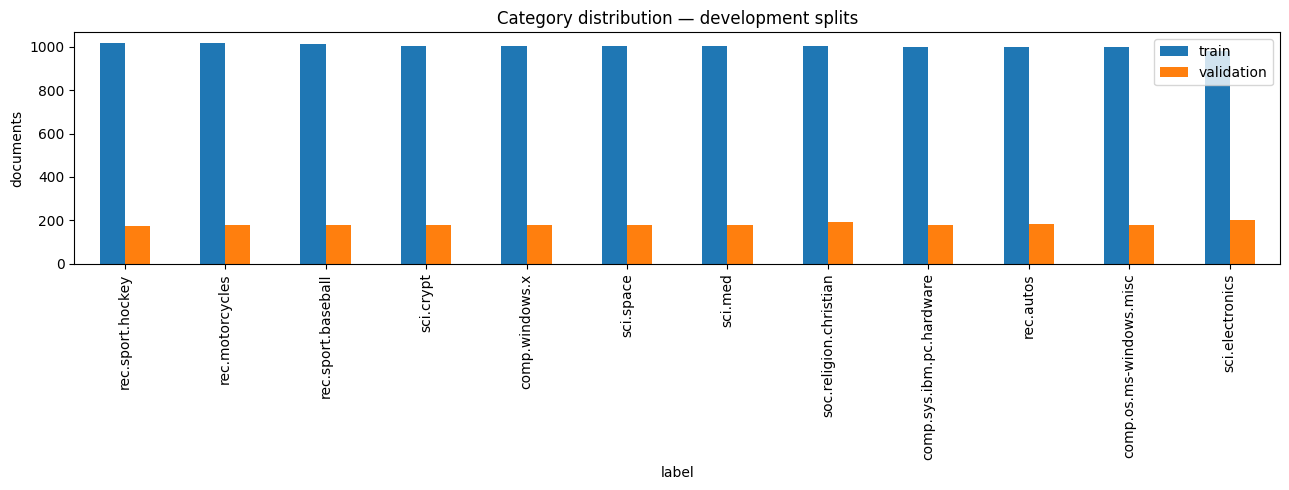

,train,validation
language,,
es,6022,1093
en,6022,1093


language,en,es
label,,
comp.os.ms-windows.misc,589,589
comp.sys.ibm.pc.hardware,589,589
comp.windows.x,592,592
rec.autos,591,591
rec.motorcycles,597,597
rec.sport.baseball,596,596
rec.sport.hockey,596,596
sci.crypt,593,593
sci.electronics,591,591


In [3]:
category_counts = pd.concat(
    [frame["label"].value_counts().rename(name) for name, frame in dev.items()], axis=1
).fillna(0).astype(int)
display(category_counts)
category_counts.plot(kind="bar", figsize=(13, 5), title="Category distribution — development splits")
plt.ylabel("documents"); plt.tight_layout(); plt.show()

language_counts = pd.concat(
    [frame["language"].value_counts().rename(name) for name, frame in dev.items()], axis=1
).fillna(0).astype(int)
display(language_counts)

dev_data = pd.concat([frame.assign(split=name) for name, frame in dev.items()], ignore_index=True)
coverage = pd.crosstab(dev_data["label"], dev_data["language"])
display(coverage)
assert {"en", "es"}.issubset(set(dev_data["language"].astype(str)))
assert (coverage > 0).all().all()


,missing_text,empty_text,within_split_exact_duplicates
train,0,0,89
validation,0,0,20


words                                                 \
                      count       mean        std  min   50%    90%    95%   
split      language                                                          
train      en        6022.0  88.795915  51.086813  1.0  86.0  150.0  150.0   
           es        6022.0  87.733643  49.328726  1.0  87.0  150.0  150.0   
validation en        1093.0  89.621226  51.398921  1.0  89.0  150.0  150.0   
           es        1093.0  88.096981  49.634467  1.0  89.0  150.0  150.0   

                                  characters                               \
                       99%    max      count        mean         std  min   
split      language                                                         
train      en        150.0  150.0     6022.0  505.641647  294.216787  4.0   
           es        150.0  150.0     6022.0  522.615078  291.692914  6.0   
validation en        150.0  150.0     1093.0  509.408966  296.752540  5.0   
           es        150.0  150.0     1093.0  524.788655  293.224976  8.0   

                                                           
                       50%    90%    95%      99%     max  
split      language                                        
train      en        483.0  873.0  914.0   996.79  2409.0  
           es        517.0  889.0  920.0   977.79  1482.0  
validation en        485.0  867.0  910.4  1048.80  1565.0  
           es        527.0  881.0  913.0   989.40  1284.0

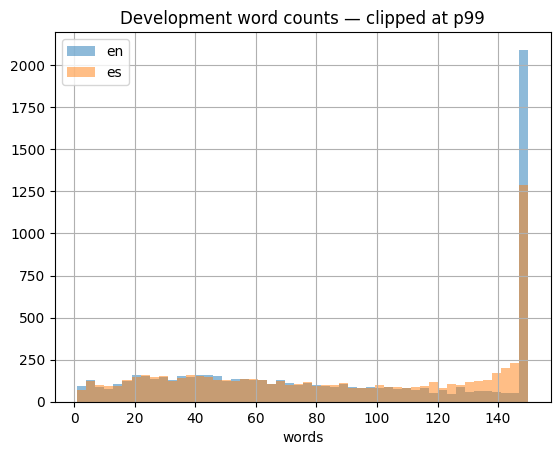

In [4]:
quality = pd.DataFrame({
    "missing_text": [int(frame["text"].isna().sum()) for frame in dev.values()],
    "empty_text": [int(frame["text"].fillna("").str.strip().eq("").sum()) for frame in dev.values()],
    "within_split_exact_duplicates": [int(frame["text"].duplicated().sum()) for frame in dev.values()],
}, index=dev.keys())
display(quality)
assert quality[["missing_text", "empty_text"]].to_numpy().sum() == 0
assert preflight["design_splits"]["train_validation_exact_text_overlap"] == 0

for name, frame in dev.items():
    if {"pair_id", "language"}.issubset(frame.columns):
        assert frame.groupby("pair_id")["language"].nunique().eq(2).all(), name

lengths = dev_data[["split", "language", "text"]].copy()
lengths["words"] = lengths["text"].astype(str).str.split().str.len()
lengths["characters"] = lengths["text"].astype(str).str.len()
display(lengths.groupby(["split", "language"])[["words", "characters"]].describe(percentiles=[.5,.9,.95,.99]))

for language, group in lengths.groupby("language"):
    group["words"].clip(upper=group["words"].quantile(.99)).hist(alpha=.5, bins=50, label=language)
plt.legend(); plt.title("Development word counts — clipped at p99"); plt.xlabel("words"); plt.show()


In [5]:
display(
    dev_data.groupby(["split", "language", "label"], group_keys=False)
    .head(1)[["split", "language", "label", "text"]]
    .head(24)
)


,split,language,label,text
0,train,es,comp.sys.ibm.pc.hardware,Compatibilidad con Drive/Controller Gracias a ...
1,train,en,sci.space,Looking for a little research help [ addendum]...
2,train,es,rec.sport.baseball,RÉGIMEN DE HITTER DESIGNADO
3,train,en,rec.sport.hockey,Bridgman is out Trashy move from a trashy orga...
4,train,es,sci.med,Convulsiones (espasmos infantiles ) La razón p...
5,train,es,soc.religion.christian,La arrogancia de los cristianos ¿Por qué segui...
7,train,en,sci.electronics,Emergency Vehicle Sensors? traffic-light-phrea...
8,train,en,rec.sport.baseball,Astros Are Back While Atlanta has the undisput...
9,train,es,sci.crypt,Hoja informativa sobre la gestión del cifrado ...
10,train,en,comp.windows.x,Motif maling list The motif mailing list will ...


## 3. Revision 2 preprocessing

Model representation:

```text
Subject without repeated leading Re:

Body
```

Routing/sender metadata is dropped. `sklearn` removes footers and quoted reply content; structural and token-density filters run next. Classification uses a deterministic **150-word** source window. Spanish is translated from the cleaned English representation and normalized again. Cross-split exact-text leakage is removed by dropping whole EN/ES pairs.

Repeated `Re:` markers were removed because a train-only diagnostic showed strong category association above the pre-registered threshold; they were treated as an accidental cue rather than useful document content.


In [6]:
display(pd.DataFrame(preflight["token_budget"]["rows"]))
display(pd.Series(preflight["translation"], name="translation sanity").to_frame())
print("Model:", preflight["token_budget"]["model_name"])
print("Classification source window: 150 words")
print("Test metrics used for model selection:", preflight["model_selection_metrics_from_test"])


,split,language,documents,p50,p95,p99,max,over_256,over_512
0,train,en,6022,138.0,255.0,288.00,1775,276,6
1,train,es,6022,156.0,268.0,285.00,1095,753,4
2,validation,en,1093,144.0,257.0,292.16,658,58,3
3,validation,es,1093,158.0,269.0,284.00,478,138,0


,translation sanity
eligible_pairs,6809.000000
word_ratio_p01,0.647241
word_ratio_p50,1.000000
word_ratio_p95,1.155556
word_ratio_p99,1.266667
word_ratio_outliers_below_0_5_or_above_2,23.000000


Model: microsoft/mdeberta-v3-base
Classification source window: 150 words
Test metrics used for model selection: False


## 4. Baseline and transfer learning

Baseline: **TF-IDF word unigrams + Logistic Regression** on the same Revision 2 development data.

Current classifier: `microsoft/mdeberta-v3-base`, fine-tuned with TensorFlow/Keras for 5 epochs.

Frozen training configuration: LR `2e-5`, batch size `2`, max model tokens `512`, AdamW, weight decay `0.01`, 10% warmup, global gradient clip `1.0`.

Checkpoint selection is deterministic: highest validation correct-document count → lower validation loss → earlier epoch. Revision 2 selected **epoch 5: 1,886 / 2,186 correct (86.28%)**.


,TF-IDF + Logistic Regression
validation_accuracy,0.805581
validation_macro_f1,0.807312
english_accuracy,0.818847
spanish_accuracy,0.792315


,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.640817,1.200798,0.789570,1.318540
1,2,0.911989,0.522311,0.813358,1.368256
2,3,0.951179,0.307917,0.835316,1.293952
3,4,0.972600,0.167125,0.852699,1.344861
4,5,0.987131,0.086102,0.862763,1.316576


,selected checkpoint
best_epoch,5
best_val_accuracy,0.862763
best_val_loss,1.316576
correct_documents,1886
validation_documents,2186
selection_rule,"[highest validation correct-document count, lo..."


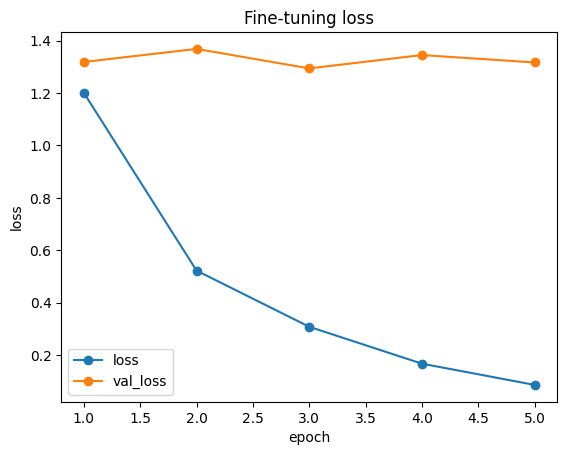

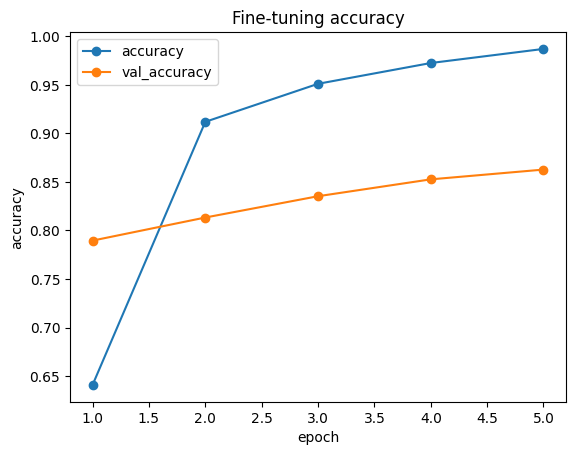

In [7]:
baseline = pd.Series({
    "validation_accuracy": preflight["baseline_validation"]["accuracy"],
    "validation_macro_f1": preflight["baseline_validation"]["macro_f1"],
    "english_accuracy": preflight["baseline_validation"]["per_language"]["en"]["accuracy"],
    "spanish_accuracy": preflight["baseline_validation"]["per_language"]["es"]["accuracy"],
}, name="TF-IDF + Logistic Regression")
display(baseline.to_frame())

history = pd.read_csv(REPORTS / "revision2" / "training_history.csv")
history["epoch"] = history["epoch"] + 1
display(history)
display(pd.Series(checkpoint_selection, name="selected checkpoint").to_frame())

history.plot(x="epoch", y=["loss", "val_loss"], marker="o", title="Fine-tuning loss")
plt.ylabel("loss"); plt.show()
history.plot(x="epoch", y=["accuracy", "val_accuracy"], marker="o", title="Fine-tuning accuracy")
plt.ylabel("accuracy"); plt.show()


Training accuracy reaches ~98.7% while validation accuracy finishes at ~86.3%, so the run has a clear generalization gap. Validation loss is non-monotonic and reaches its minimum before the selected epoch. The selected checkpoint follows the frozen correct-document rule; validation loss remains a monitored diagnostic and tie-breaker.


## 5. Calibration and frozen runtime

The selected classifier uses scalar temperature scaling fitted on **validation only**. Calibration preserves argmax and changes confidence estimates, not predicted categories.

Release runtime: float32 + XLA, token buckets `64/128/192/256/384/512`, attention-balanced classifier batch sizes `32/32/16/16/4/4`, 150-word classification window, 75-word spaCy tagging window, and parallel classifier/tagger stages.


In [8]:
calibration_summary = pd.DataFrame({
    "before": {
        "accuracy": calibration["before"]["accuracy"],
        "mean_confidence": calibration["before"]["mean_confidence"],
        "NLL": calibration["before"]["nll"],
        "ECE": calibration["before"]["ece"],
        "Brier": calibration["before"]["brier"],
    },
    "after": {
        "accuracy": calibration["after"]["accuracy"],
        "mean_confidence": calibration["after"]["mean_confidence"],
        "NLL": calibration["after"]["nll"],
        "ECE": calibration["after"]["ece"],
        "Brier": calibration["after"]["brier"],
    },
})
display(calibration_summary)
print("Temperature:", calibration["temperature"], "| argmax unchanged:", calibration["argmax_unchanged"])

runtime = pd.Series({
    "validation_accuracy": production_validation["accuracy"],
    "validation_macro_f1": production_validation["macro_f1"],
    "mean_calibrated_confidence": production_validation["mean_calibrated_confidence"],
    "end_to_end_docs_per_sec": production_validation["processing_speed_docs_per_sec"],
    "english_accuracy": production_validation["per_language"]["en"]["accuracy"],
    "spanish_accuracy": production_validation["per_language"]["es"]["accuracy"],
    "selected_correct": production_validation["selection_verification"]["selected_correct_documents"],
    "observed_correct": production_validation["selection_verification"]["observed_correct_documents"],
    "exact_correct_count_match": production_validation["selection_verification"]["exact_correct_count_match"],
}, name="frozen validation runtime")
display(runtime.to_frame())


,before,after
accuracy,0.862763,0.862763
mean_confidence,0.989698,0.878251
NLL,1.316327,0.592849
ECE,0.129206,0.045406
Brier,0.264773,0.230446


Temperature: 2.910829652923409 | argmax unchanged: True


,frozen validation runtime
validation_accuracy,0.862763
validation_macro_f1,0.863245
mean_calibrated_confidence,0.878262
end_to_end_docs_per_sec,112.361741
english_accuracy,0.874657
spanish_accuracy,0.850869
selected_correct,1886
observed_correct,1886
exact_correct_count_match,True


## 6. Recorded release evaluation

This section reads immutable report files only; it does **not** run the final evaluator or open `test.csv`.

Revision 2 is the current release. Revision 1 and Revision 2 are development history rather than a controlled A/B test because Revision 2 changed representation, category selection and validation construction before retraining. The controlled comparison inside each revision is the transformer versus its baseline on the same data.


In [9]:
comparison = pd.DataFrame({
    "Revision 1": {
        "test_accuracy": revision1_metrics["classification_accuracy"],
        "macro_f1": revision1_metrics["f1_score_macro"],
        "end_to_end_docs_per_sec": revision1_metrics["processing_speed_docs_per_sec"],
        "english_accuracy": revision1_metrics["per_language_accuracy"]["en"],
        "spanish_accuracy": revision1_metrics["per_language_accuracy"]["es"],
        "baseline_accuracy": revision1_metrics["baseline_accuracy"],
        "relative_improvement_over_baseline": revision1_metrics["accuracy_improvement_over_baseline_relative"],
        "mean_calibrated_confidence": revision1_metrics["mean_calibrated_confidence"],
    },
    "Revision 2": {
        "test_accuracy": revision2_metrics["classification_accuracy"],
        "macro_f1": revision2_metrics["f1_score_macro"],
        "end_to_end_docs_per_sec": revision2_metrics["processing_speed_docs_per_sec"],
        "english_accuracy": revision2_metrics["per_language_accuracy"]["en"],
        "spanish_accuracy": revision2_metrics["per_language_accuracy"]["es"],
        "baseline_accuracy": revision2_metrics["baseline_accuracy"],
        "relative_improvement_over_baseline": revision2_metrics["accuracy_improvement_over_baseline_relative"],
        "mean_calibrated_confidence": revision2_metrics["mean_calibrated_confidence"],
    },
})
display(comparison)

print("Current release accuracy:", f"{revision2_metrics['classification_accuracy']:.2%}")
print("Current release macro F1:", f"{revision2_metrics['f1_score_macro']:.2%}")
print("Current release throughput:", f"{revision2_metrics['processing_speed_docs_per_sec']:.2f} docs/s")

mcnemar = pd.DataFrame(revision2_metrics["significance"]["mcnemar_exact_by_language"]).T
display(mcnemar)
display(pd.Series(revision2_metrics["significance"]["cluster_bootstrap"], name="pair-cluster bootstrap").to_frame())


,Revision 1,Revision 2
test_accuracy,0.819535,0.877897
macro_f1,0.819151,0.878021
end_to_end_docs_per_sec,134.084165,130.844220
english_accuracy,0.827901,0.888538
spanish_accuracy,0.811169,0.867257
baseline_accuracy,0.778140,0.831437
relative_improvement_over_baseline,0.053197,0.055879
mean_calibrated_confidence,0.880203,0.881371


Current release accuracy: 87.79%
Current release macro F1: 87.80%
Current release throughput: 130.84 docs/s


,transformer_only_correct,baseline_only_correct,discordant_pairs,exact_two_sided_p_value
en,434.0,213.0,647.0,2.437586e-18
es,480.0,260.0,740.0,5.046882e-16


,pair-cluster bootstrap
cluster,pair_id
clusters,4746
iterations,2000
seed,42
absolute_accuracy_points_95_ci,"[0.03761061946902655, 0.0561525495153814]"
relative_accuracy_improvement_95_ci,"[0.04499300778293973, 0.06789268403749683]"


## 7. Optional optimization and reproducibility

`utils/model_optimization.py` provides a TensorFlow Lite post-training quantization path. It is separate from the validated float32/XLA release path and should be benchmarked independently before replacing it.

Key workflow:

```text
scripts/prepare_data.py
scripts/preflight_revision2.py
scripts/train_revision2.py
scripts/calibrate_validation.py
scripts/freeze_production.py
scripts/verify_production_validation.py
scripts/evaluate.py                 # displays preserved final metrics only
app/real_time_dashboard.py
```

The historical one-time Revision 2 final evaluator remains for provenance, while the completed consumption marker prevents another final-test run.
